In [1]:

import h5py
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split

class CERNLabelledDataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path
        self.h5_file = None
        
        # Open briefly to verify total length
        with h5py.File(self.file_path, 'r') as f:
            self.length = len(f['Y'])
            print(f"Loaded dataset with {self.length} total labelled jets.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Multiprocessing safeguard for HDF5
        if self.h5_file is None:
            self.h5_file = h5py.File(self.file_path, 'r')
            self.jets = self.h5_file['jet']
            self.Y = self.h5_file['Y']
            self.m = self.h5_file['m']
            self.pT = self.h5_file['pT']
            # Add this right before returning the image in __getitem__
       # Vertical flip

        # --- 1. Process the Image ---
        img = self.jets[idx] 
        img = torch.tensor(img, dtype=torch.float32)

        if img.shape[-1] == 8:
            img = img.permute(2, 0, 1)

        # Image features are also log-transformed to stabilize input
        img = torch.log1p(img)
        img = F.pad(img, (1, 2, 1, 2), mode='constant', value=0.0)

        # --- 2. Process Classification Label ---
        y_class = torch.tensor(self.Y[idx], dtype=torch.long) 
        
        # --- 3. LOG TRANSFORMATION FOR REGRESSION TARGETS ---
        # We use log1p (ln(1+x)) to handle any zero values safely.
        # This turns skewed distributions into roughly Gaussian-shaped ones.
        raw_mass = self.m[idx]
        raw_pt = self.pT[idx]
        
        y_mass = torch.tensor(np.log1p(raw_mass), dtype=torch.float32)
        y_pt = torch.tensor(np.log1p(raw_pt), dtype=torch.float32)
        if torch.rand(1).item() > 0.5:
                img = torch.flip(img, dims=[1]) # Horizontal flip
        if torch.rand(1).item() > 0.5:
            img = torch.flip(img, dims=[2])
        

        return img, y_class, y_mass, y_pt

    def __del__(self):
        if self.h5_file is not None:
            self.h5_file.close()

# --- DATALOADER CREATION ---
LABELLED_DATA_PATH = '/kaggle/input/datasets/happysaxena/cern-labelled-2/Dataset_Specific_labelled_full_only_for_2i.h5'
full_dataset = CERNLabelledDataset(LABELLED_DATA_PATH)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

batch_size = 32
train_loader_post = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_post = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Updated Sanity Check ---
print("\n--- Dataloader Sanity Check (Log-Transformed) ---")
for imgs, classes, masses, pts in train_loader_post:
    print(f"Images Shape:  {imgs.shape}")
    # print(f"Classes Range: {classes.min().item()} to {classes.max().item()}")
    print(f"Masses (Logged) Mean/Std: {masses.mean():.4f} / {masses.std():.4f}")
    print(f"pT (Logged) Mean/Std:     {pts.mean():.4f} / {pts.std():.4f}")
    break

Loaded dataset with 10000 total labelled jets.

--- Dataloader Sanity Check (Log-Transformed) ---
Images Shape:  torch.Size([32, 8, 128, 128])
Masses (Logged) Mean/Std: 4.8111 / 0.3903
pT (Logged) Mean/Std:     6.2647 / 0.1595


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- UTILITIES ---
def to_2tuple(x):
    return x if isinstance(x, tuple) else (x, x)

class DropPath(nn.Module):
    """Stochastic Depth (DropPath) implementation to avoid `timm` dependency."""
    def __init__(self, drop_prob=0.):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        return x.div(keep_prob) * random_tensor

class Mlp(nn.Module):
    """Standard Feed-Forward Network"""
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class CPE(nn.Module):
    """Conditional Positional Encoding using a 3x3 depthwise convolution."""
    def __init__(self, dim, k=3):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim, kernel_size=k, stride=1, padding=k//2, groups=dim)

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        # Reshape to 2D image format (B, C, H, W)
        feat = x.transpose(1, 2).contiguous().view(B, C, H, W)
        feat = self.proj(feat)
        # Flatten back to sequence (B, N, C)
        feat = feat.flatten(2).transpose(1, 2)
        return x + feat

# --- TEST STEP 1 ---
if __name__ == "__main__":
    dummy_x = torch.randn(2, 3136, 96) # Batch=2, Seq=3136 (56x56), Dim=96
    cpe = CPE(dim=96)
    out = cpe(dummy_x, size=(56, 56))
    print("Step 1 (CPE) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 1 (CPE) Output Shape: torch.Size([2, 3136, 96])


In [3]:
class ConvStem(nn.Module):
    """Initial Convolutional Stem: Downsamples image by 4x."""
    def __init__(self, in_chans, embed_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.ReLU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
        )

    def forward(self, x):
        return self.proj(x)

class PatchEmbed(nn.Module):
    """Acts as the Stem (Stage 0) or Downsampler (Stages 1, 2, 3)."""
    def __init__(self, patch_size=16, in_chans=3, embed_dim=96, is_stem=False):
        super().__init__()
        self.patch_size = to_2tuple(patch_size)
        self.is_stem = is_stem
        
        if self.is_stem: # Stage 0
            self.proj = ConvStem(in_chans, embed_dim)
            self.norm = nn.LayerNorm(embed_dim)
        else: # Patch Merging between stages
            self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=2, stride=2)
            self.norm = nn.LayerNorm(in_chans)

    def forward(self, x, size=None):
        if len(x.shape) == 3: # If input is a sequence (B, L, C)
            B, HW, C = x.shape
            H, W = size
            x = self.norm(x)
            x = x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()

        x = self.proj(x)
        newsize = (x.size(2), x.size(3))
        x = x.flatten(2).transpose(1, 2)
        
        if self.is_stem:
            x = self.norm(x)
        return x, newsize

# --- TEST STEP 2 ---
if __name__ == "__main__":
    dummy_img = torch.randn(2, 3, 224, 224) # Standard 224x224 image
    stem = PatchEmbed(patch_size=4, in_chans=3, embed_dim=96, is_stem=True)
    out, newsize = stem(dummy_img)
    print(f"Step 2 (Stem) Output Shape: {out.shape}, New Grid Size: {newsize}") 
    # Expected: [2, 3136, 96], Size: (56, 56)

Step 2 (Stem) Output Shape: torch.Size([2, 3136, 96]), New Grid Size: (56, 56)


In [4]:
def window_partition(x, window_size: int):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size: int, H: int, W: int):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    """Standard Self-Attention restricted to local windows."""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj(x)

class LWABlock(nn.Module):
    """Local Window Attention Block"""
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.cpe = nn.ModuleList([CPE(dim), CPE(dim)])
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, num_heads)
        self.drop_path = DropPath(drop_path)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio))

    def forward(self, x, size):
        H, W = size
        B, L, C = x.shape

        shortcut = self.cpe[0](x, size)
        x = self.norm1(shortcut).view(B, H, W, C)

        # Pad feature maps if they aren't divisible by window_size
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, 0, pad_r, 0, pad_b))
        _, Hp, Wp, _ = x.shape

        # Partition -> Attend -> Reverse
        x_windows = window_partition(x, self.window_size).view(-1, self.window_size**2, C)
        attn_windows = self.attn(x_windows)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, Hp, Wp)

        # Remove padding
        if pad_r > 0 or pad_b > 0:
            x = x[:, :H, :W, :].contiguous()

        x = shortcut + self.drop_path(x.view(B, H * W, C))
        
        # FFN Part
        x = self.cpe[1](x, size)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size

# --- TEST STEP 3 ---
if __name__ == "__main__":
    lwa = LWABlock(dim=96, num_heads=3)
    out, _ = lwa(out, newsize) # Uses outputs from Step 2
    print("Step 3 (LWA Block) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 3 (LWA Block) Output Shape: torch.Size([2, 3136, 96])


In [5]:
class LinearAttention(nn.Module):
    """O(N) Complexity Attention mechanism"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        # Learnable temperature to replace Softmax normalization effect
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1) * self.scale)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # ReLU mapping ensures non-negativity (crucial for Linear Attention)
        q = self.act(q)
        k = self.act(k)
        
        # Calculate K^T * V first! (This is where O(N^2) becomes O(N))
        kv = (k.transpose(-2, -1) @ v) * self.temperature
        
        # Calculate denominator and clamp to prevent dividing by zero
        k_sum = k.transpose(-2, -1).sum(dim=-1, keepdim=True)
        denom = torch.clamp(q @ k_sum, min=1e-2)

        attn = (q @ kv) / denom
        
        x = attn.transpose(1, 2).reshape(B, N, C)
        return self.proj(x)

class LCM(nn.Module):
    """Local Concentration Module: Refocuses linear attention locally."""
    def __init__(self, dim, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim)
        self.act = nn.GELU()
        self.bn = nn.BatchNorm2d(dim)
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim)

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        x = x.transpose(-1, -2).contiguous().view(B, C, H, W)
        x = self.conv2(self.bn(self.act(self.conv1(x))))
        return x.flatten(2).transpose(-1, -2)

class LGABlock(nn.Module):
    """Linear Global Attention Block"""
    def __init__(self, dim, num_heads, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.cpe = nn.ModuleList([CPE(dim)])
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads)
        self.drop_path = DropPath(drop_path)
        
        self.norm3 = nn.LayerNorm(dim)
        self.local_mp = LCM(dim)
        
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio))

    def forward(self, x, size):
        # 1. CPE & Linear Attn
        x = self.cpe[0](x, size)
        cur = self.attn(self.norm1(x))
        x = x + self.drop_path(cur)
        
        # 2. LCM
        x = x + self.drop_path(self.local_mp(self.norm3(x), size))
        
        # 3. FFN
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size

# --- TEST STEP 4 ---
if __name__ == "__main__":
    lga = LGABlock(dim=96, num_heads=3)
    out, _ = lga(out, newsize)
    print("Step 4 (LGA Block) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 4 (LGA Block) Output Shape: torch.Size([2, 3136, 96])


In [6]:

import torch
import torch.nn as nn

class L2ViT_Tiny_CERN(nn.Module):
    """L2ViT-Tiny adapted for CERN Task 2h: 
       Simultaneous Classification + Mass Regression (+ optional Momentum Regression)
    """
    def __init__(self, in_chans=3, num_classes=2, drop_path_rate=0.3, include_momentum=False):
        super().__init__()
        self.include_momentum = include_momentum
        
        # L2ViT-Tiny Configurations
        depths = [2, 2, 6, 2]
        dims =[96, 192, 384, 768]
        num_heads =[3, 6, 12, 24]
        
        # 1. Patch Embeddings (Downsampling layers)
        self.downsample_layers = nn.ModuleList()
        for i in range(4):
            embed = PatchEmbed(
                patch_size=4 if i == 0 else 2,
                in_chans=in_chans if i == 0 else dims[i - 1],
                embed_dim=dims[i],
                is_stem=(i == 0)
            )
            self.downsample_layers.append(embed)

        # 2. Transformer Stages
        self.stages = nn.ModuleList()
        dp_rates =[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))] 
        cur = 0
        
        for i in range(4):
            blocks =[]
            for j in range(depths[i]):
                # Alternating LWA and LGA blocks
                if j % 2 == 0:
                    blocks.append(LWABlock(dims[i], num_heads[i], drop_path=dp_rates[cur + j]))
                else:
                    blocks.append(LGABlock(dims[i], num_heads[i], drop_path=dp_rates[cur + j]))
            self.stages.append(nn.ModuleList(blocks))
            cur += depths[i]

        # 3. Final Norm and Global Average Pooling
        self.norm = nn.LayerNorm(dims[-1])
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # 4. Task 2h Specific Heads
        # Base tasks: Classification and Mass Regression
        self.cls_head = nn.Linear(dims[-1], num_classes) # Particle ID
        self.mass_head = nn.Linear(dims[-1], 1)          # Mass Regression
        
        # Optional task: Momentum Regression
        if self.include_momentum:
            self.mom_head = nn.Linear(dims[-1], 1)   
            
    # Momentum Regression
    def forward_features(self, x):
        size = [x.size(2), x.size(3)]
        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            for block in self.stages[i]:
                x, size = block(x, size)
        x = self.norm(x)
        B, N, C = x.shape
        H, W = size
        return x.transpose(1, 2).view(B, C, H, W)

    def forward(self, x):
        size =[x.size(2), x.size(3)]
        
        # Pass through the 4 hierarchical stages
        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            for block in self.stages[i]:
                x, size = block(x, size)
                
        # Aggregate global features
        x = self.norm(x)
        x = self.avgpool(x.transpose(1, 2)).flatten(1) # Final shape: (Batch, 768)
        
        # Base Output Dictionary
        outputs = {
            'class_logits': self.cls_head(x),
            'mass_pred': self.mass_head(x)
        }
        
        # Add momentum prediction if the head was initialized
        if self.include_momentum:
            outputs['mom_pred'] = self.mom_head(x)
            
        return outputs

# --- TEST FINAL FLOW ---
if __name__ == "__main__":
    print("\n--- FINAL MODEL VALIDATION ---")
    
    # Random batch of Images (Batch=4, Channels=3, H=224, W=224)
    # Note: Check your .h5 file for the exact number of channels the CERN data uses!
    dummy_input = torch.randn(4, 3, 224, 224)
    
    print("\nTest 1: Strategy A (Classification + Mass only)")
    model_A = L2ViT_Tiny_CERN(in_chans=3, num_classes=2, include_momentum=False)
    outputs_A = model_A(dummy_input)
    print("Keys in output:", outputs_A.keys())
    print("Class Output Shape:", outputs_A['class_logits'].shape) # Expected:[4, 2]
    print("Mass Output Shape:", outputs_A['mass_pred'].shape)     # Expected: [4, 1]
    
    print("\nTest 2: Strategy B (Classification + Mass + Momentum)")
    model_B = L2ViT_Tiny_CERN(in_chans=3, num_classes=2, include_momentum=True)
    outputs_B = model_B(dummy_input)
    print("Keys in output:", outputs_B.keys())
    print("Class Output Shape:", outputs_B['class_logits'].shape) # Expected: [4, 2]
    print("Mass Output Shape:", outputs_B['mass_pred'].shape)     # Expected:[4, 1]
    print("Mom Output Shape:", outputs_B['mom_pred'].shape)       # Expected:[4, 1]
    print("\nForward Pass Successful for both strategies!")


--- FINAL MODEL VALIDATION ---

Test 1: Strategy A (Classification + Mass only)
Keys in output: dict_keys(['class_logits', 'mass_pred'])
Class Output Shape: torch.Size([4, 2])
Mass Output Shape: torch.Size([4, 1])

Test 2: Strategy B (Classification + Mass + Momentum)
Keys in output: dict_keys(['class_logits', 'mass_pred', 'mom_pred'])
Class Output Shape: torch.Size([4, 2])
Mass Output Shape: torch.Size([4, 1])
Mom Output Shape: torch.Size([4, 1])

Forward Pass Successful for both strategies!


In [7]:
# class DualTaskLoss(nn.Module):
#     def __init__(self, include_momentum=False, w_cls=1.0, w_mass=1.0, w_mom=1.0):
#         super().__init__()
#         self.include_momentum = include_momentum
#         self.criterion_cls = nn.CrossEntropyLoss()
#         self.criterion_reg = nn.MSELoss()
        
#         # Weights to balance the losses
#         self.w_cls = w_cls
#         self.w_mass = w_mass
#         self.w_mom = w_mom

#     def forward(self, outputs, target_cls, target_mass, target_mom=None):
#         # 1. Classification Loss
#         loss_cls = self.criterion_cls(outputs['class_logits'], target_cls)
        
#         # 2. Mass Loss (Squeeze to ensure shape matching)
#         loss_mass = self.criterion_reg(outputs['mass_pred'].squeeze(), target_mass)
        
#         # Total Loss
#         total_loss = (self.w_cls * loss_cls) + (self.w_mass * loss_mass)
        
#         if self.include_momentum and target_mom is not None:
#             loss_mom = self.criterion_reg(outputs['mom_pred'].squeeze(), target_mom)
#             total_loss += (self.w_mom * loss_mom)
#             return total_loss, loss_cls, loss_mass, loss_mom
            
#         return total_loss, loss_cls, loss_mass

class DualTaskLoss(nn.Module):
    def __init__(self, include_momentum=False, w_cls=1.0, w_mass=1.0, w_mom=0.5):
        super().__init__()
        self.include_momentum = include_momentum
        self.criterion_cls = nn.CrossEntropyLoss()
        self.criterion_reg = nn.MSELoss()
        
        # Weights to balance the losses
        self.w_cls = w_cls
        self.w_mass = w_mass
        self.w_mom = w_mom

    def forward(self, outputs, target_cls, target_mass, target_mom=None):
        
        # ==========================================
        # 1. FIX CLASSIFICATION TARGET SHAPE
        # ==========================================
        # If target is (Batch, 1), squeeze it to (Batch,)
        if target_cls.dim() > 1 and target_cls.shape[1] == 1:
            target_cls = target_cls.squeeze(1)
            
        # If target is one-hot encoded (Batch, 2), convert to class index (Batch,)
        elif target_cls.dim() > 1 and target_cls.shape[1] > 1:
            target_cls = torch.argmax(target_cls, dim=1)
            
        # CrossEntropyLoss requires the targets to be LongTensors (integers)
        target_cls = target_cls.long()
        
        loss_cls = self.criterion_cls(outputs['class_logits'], target_cls)
        
        # ==========================================
        # 2. FIX MASS REGRESSION TARGET SHAPE
        # ==========================================
        # .view(-1) forcefully flattens both arrays to exactly (Batch,)
        # This prevents PyTorch from accidentally creating a huge (B, B) matrix
        pred_mass = outputs['mass_pred'].view(-1)
        target_mass = target_mass.view(-1).float()
        
        loss_mass = self.criterion_reg(pred_mass, target_mass)
        
        total_loss = (self.w_cls * loss_cls) + (self.w_mass * loss_mass)
        
        # ==========================================
        # 3. FIX MOMENTUM REGRESSION TARGET SHAPE
        # ==========================================
        if self.include_momentum and target_mom is not None:
            pred_mom = outputs['mom_pred'].view(-1)
            target_mom = target_mom.view(-1).float()
            
            loss_mom = self.criterion_reg(pred_mom, target_mom)
            total_loss += (self.w_mom * loss_mom)
            return total_loss, loss_cls, loss_mass, loss_mom
            
        return total_loss, loss_cls, loss_mass

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import copy


import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    r2_score,
    roc_curve,
    roc_auc_score
)


def train_supervised_from_scratch(train_loader, val_loader, epochs=50, lr=1e-3, 
                                  include_momentum=False, patience=7, device='cuda', 
                                  save_path='l2vit_tiny_scratch.pth'):
    
    print(f"Training L2ViT FROM SCRATCH on Labelled Data...")
    
    # 1. Instantiate the Model
    model = L2ViT_Tiny_CERN(in_chans=8, num_classes=2, include_momentum=include_momentum).to(device)
    
    # 2. Optimizer & Scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = DualTaskLoss(include_momentum=include_momentum)
    
    # 3. Tracking variables for Early Stopping and Plotting
    history = {
        'train_loss':[], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_r2_mass':[], 'val_r2_mass': [],
        'train_r2_mom':[], 'val_r2_mom':[]
    }
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_preds_for_roc = {}  # Store for final ROC plot
    
    for epoch in range(epochs):
        # ==========================================
        # TRAINING PHASE
        # ==========================================
        model.train()
        train_loss = 0.0
        
        # Lists to store batch predictions for epoch-level metrics
        t_cls_all, p_cls_all, prob_cls_all = [], [], []
        t_mass_all, p_mass_all = [],[]
        t_mom_all, p_mom_all = [],[]
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in progress_bar:
            if include_momentum:
                imgs, t_cls, t_mass, t_mom = [b.to(device) for b in batch]
            else:
                imgs, t_cls, t_mass,t_mom = [b.to(device) for b in batch]
                t_mom = None
                
            optimizer.zero_grad()
            outputs = model(imgs)
            
            # Compute Loss
            if include_momentum:
                loss, _, _, _ = criterion(outputs, t_cls, t_mass, t_mom)
                t_mom_all.extend(t_mom.detach().cpu().numpy())
                p_mom_all.extend(outputs['mom_pred'].squeeze().detach().cpu().numpy())
            else:
                loss, _, _ = criterion(outputs, t_cls, t_mass)
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            
            # Store predictions for metrics
            t_cls_all.extend(t_cls.detach().cpu().numpy())
            p_cls_all.extend(torch.argmax(outputs['class_logits'], dim=1).detach().cpu().numpy())
            prob_cls_all.extend(F.softmax(outputs['class_logits'], dim=1)[:, 1].detach().cpu().numpy()) # Prob of class 1
            
            t_mass_all.extend(t_mass.detach().cpu().numpy())
            p_mass_all.extend(outputs['mass_pred'].squeeze().detach().cpu().numpy())
            
            progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})
            
        scheduler.step()
        
        # Calculate Training Metrics
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(accuracy_score(t_cls_all, p_cls_all))
        history['train_r2_mass'].append(r2_score(t_mass_all, p_mass_all))
        if include_momentum:
            history['train_r2_mom'].append(r2_score(t_mom_all, p_mom_all))

        # ==========================================
        # VALIDATION PHASE
        # ==========================================
        model.eval()
        val_loss = 0.0
        vt_cls_all, vp_cls_all, vprob_cls_all = [], [],[]
        vt_mass_all, vp_mass_all = [], []
        vt_mom_all, vp_mom_all =[],[]
        
        with torch.no_grad():
            for batch in val_loader:
                if include_momentum:
                    imgs, t_cls, t_mass, t_mom =[b.to(device) for b in batch]
                else:
                    imgs, t_cls, t_mass,t_mom = [b.to(device) for b in batch]
                    t_mom = None
                    
                outputs = model(imgs)
                
                if include_momentum:
                    loss, _, _, _ = criterion(outputs, t_cls, t_mass, t_mom)
                    vt_mom_all.extend(t_mom.cpu().numpy())
                    vp_mom_all.extend(outputs['mom_pred'].squeeze().cpu().numpy())
                else:
                    loss, _, _ = criterion(outputs, t_cls, t_mass)
                    
                val_loss += loss.item()
                
                vt_cls_all.extend(t_cls.cpu().numpy())
                vp_cls_all.extend(torch.argmax(outputs['class_logits'], dim=1).cpu().numpy())
                vprob_cls_all.extend(F.softmax(outputs['class_logits'], dim=1)[:, 1].cpu().numpy())
                
                vt_mass_all.extend(t_mass.cpu().numpy())
                vp_mass_all.extend(outputs['mass_pred'].squeeze().cpu().numpy())

        # Calculate Validation Metrics
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = accuracy_score(vt_cls_all, vp_cls_all)
        epoch_val_r2 = r2_score(vt_mass_all, vp_mass_all)
        
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['val_r2_mass'].append(epoch_val_r2)
        
        if include_momentum:
            epoch_val_r2_mom = r2_score(vt_mom_all, vp_mom_all)
            history['val_r2_mom'].append(epoch_val_r2_mom)
            print(f"Epoch {epoch+1} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | Val R2(Mass): {epoch_val_r2:.4f} | Val R2(Mom): {epoch_val_r2_mom:.4f}")
        else:
            print(f"Epoch {epoch+1} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | Val R2(Mass): {epoch_val_r2:.4f}")

        # ==========================================
        # EARLY STOPPING
        # ==========================================
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            # Save predictions for the best epoch to plot the ROC curve later
            best_val_preds_for_roc = {'targets': vt_cls_all, 'probs': vprob_cls_all}
            torch.save(best_model_wts, save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs! Best Val Loss: {best_val_loss:.4f}")
                break

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print("Training Complete. Best model restored and saved.")

    # ==========================================
    # PLOTTING METRICS
    # ==========================================
    plot_training_results(history, best_val_preds_for_roc, include_momentum)
    
    return model

def plot_training_results(history, roc_data, include_momentum):
    """Helper function to plot Loss, Accuracy, R2, and ROC curves."""
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    # Setup subplots
    num_plots = 4 if include_momentum else 3
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))
    if num_plots == 3: axes = list(axes) + [None] # Padding if momentum is false
    
    # 1. Loss Curve
    axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o')
    axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='red', marker='x')
    axes[0].set_title('Compound Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # 2. Accuracy Curve
    axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='blue', marker='o')
    axes[1].plot(epochs_range, history['val_acc'], label='Val Acc', color='red', marker='x')
    axes[1].set_title('Classification Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    # 3. R2 Score (Mass)
    axes[2].plot(epochs_range, history['train_r2_mass'], label='Train R2 (Mass)', color='blue', marker='o')
    axes[2].plot(epochs_range, history['val_r2_mass'], label='Val R2 (Mass)', color='red', marker='x')
    axes[2].set_title('Mass Regression ($R^2$ Score)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('$R^2$')
    axes[2].set_ylim([-1, 1.1]) # R2 can be negative, but let's constrain the view
    axes[2].legend()
    axes[2].grid(True)

    # 4. R2 Score (Momentum) or ROC Curve
    target_ax = axes[3] if include_momentum else axes[2] # We will create a new figure for ROC if 4 plots are filled
    
    if include_momentum:
        axes[3].plot(epochs_range, history['train_r2_mom'], label='Train R2 (Mom)', color='blue', marker='o')
        axes[3].plot(epochs_range, history['val_r2_mom'], label='Val R2 (Mom)', color='red', marker='x')
        axes[3].set_title('Momentum Regression ($R^2$ Score)')
        axes[3].set_xlabel('Epoch')
        axes[3].set_ylabel('$R^2$')
        axes[3].set_ylim([-1, 1.1])
        axes[3].legend()
        axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    # 5. ROC Curve (Plotted separately for clarity)
    fpr, tpr, thresholds = roc_curve(roc_data['targets'], roc_data['probs'])
    roc_auc = roc_auc_score(roc_data['targets'], roc_data['probs'])
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1],[0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Best Epoch')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

Training L2ViT FROM SCRATCH on Labelled Data...


Epoch 1/50 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.4002 | Val Loss: 0.4885 | Val Acc: 0.8295 | Val R2(Mass): 0.4881 | Val R2(Mom): -0.3704


Epoch 2/50 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.5172 | Val Loss: 0.5439 | Val Acc: 0.8275 | Val R2(Mass): 0.4851 | Val R2(Mom): -0.4387


...

Epoch 24 | Train Loss: 0.2656 | Val Loss: 0.3700 | Val Acc: 0.8875 | Val R2(Mass): 0.7718 | Val R2(Mom): 0.0758


Epoch 25/50 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 25 | Train Loss: 0.2595 | Val Loss: 0.3596 | Val Acc: 0.8895 | Val R2(Mass): 0.7338 | Val R2(Mom): -0.1552


Epoch 26/50 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 26 | Train Loss: 0.2552 | Val Loss: 0.3377 | Val Acc: 0.8775 | Val R2(Mass): 0.7721 | Val R2(Mom): 0.0850

Early stopping triggered after 26 epochs! Best Val Loss: 0.3022
Training Complete. Best model restored and saved.


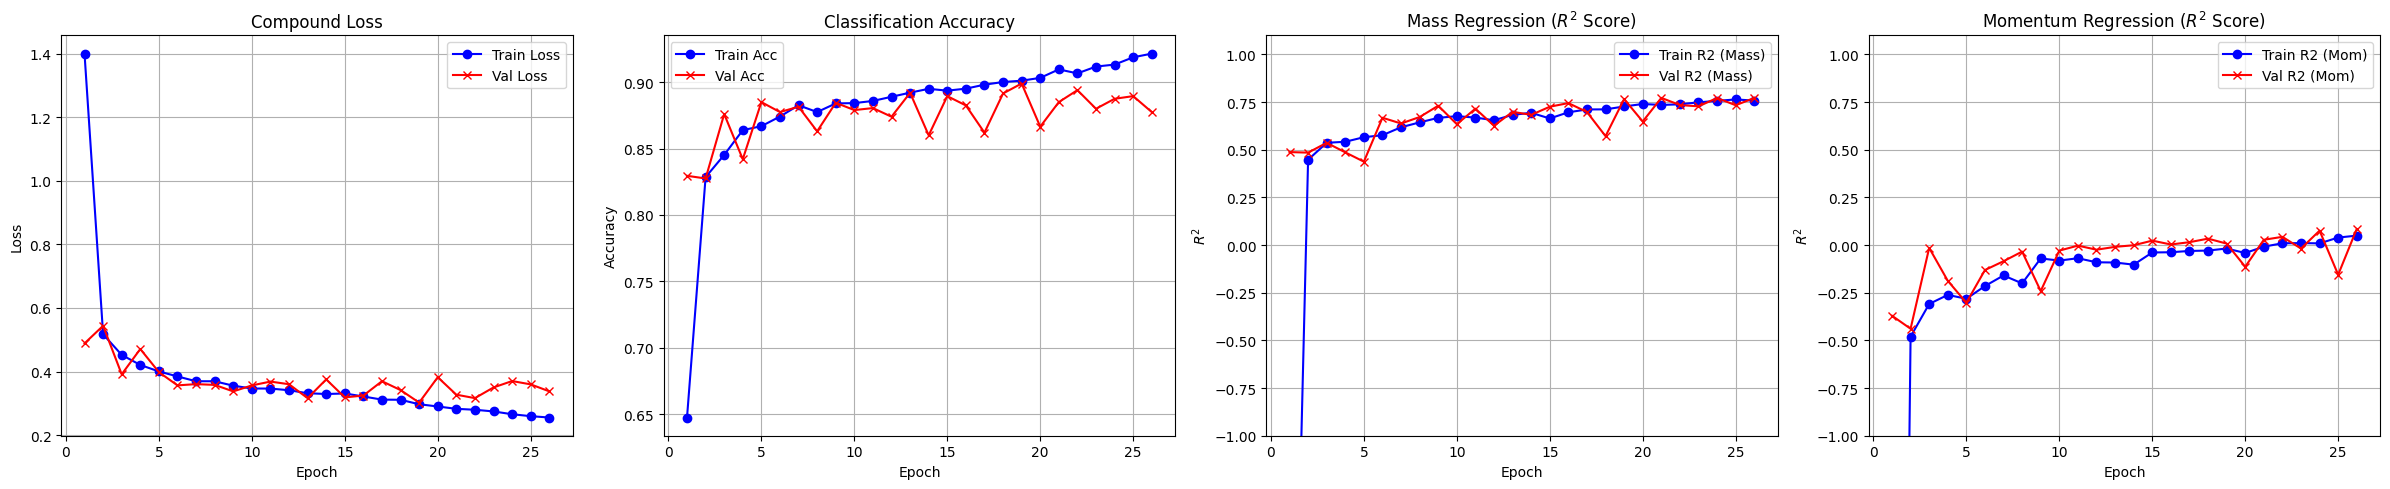

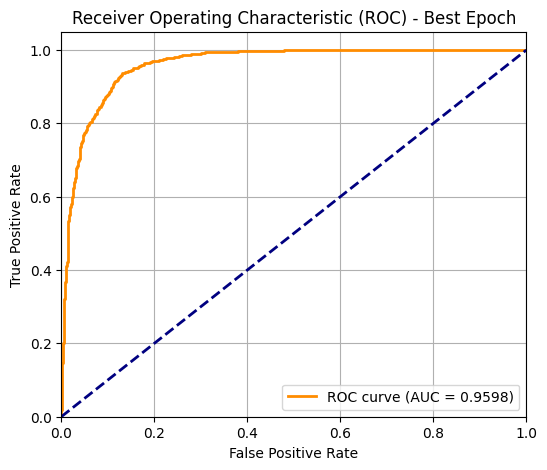

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_scratch = train_supervised_from_scratch(
    train_loader_post, 
    val_loader_post,
    epochs=50, 
    lr=1e-3, 
    include_momentum=True, 
    device=device
)